In [1]:
import pandas as pd

# Cargo el archivo csv
df = pd.read_csv('auto-mpg.csv')

# Se muestra las primeras 5 filas donde se ven los datos están listos
print("¡Dataset cargado correctamente!")
df.head()

¡Dataset cargado correctamente!


,mpg,cylinders,displacement,horsepower,weight,acceleration,model-year
0,18.0,8,307.0,130.0,3504,12.0,70
1,15.0,8,350.0,165.0,3693,11.5,70
2,18.0,8,318.0,150.0,3436,11.0,70
3,16.0,8,304.0,150.0,3433,12.0,70
4,17.0,8,302.0,140.0,3449,10.5,70


## ¿De qué trata este trabajo y qué vamos a predecir?

Bueno, agarré un dataset de carros viejos para ver qué es lo que hace que un carro gaste más o menos gasolina.

El dataset **Auto MPG** viene de la UCI Machine Learning Repository y recopila datos de vehículos fabricados entre 1970 y 1982 en Estados Unidos, Europa y Japón. Los datos fueron recolectados originalmente para estudiar el consumo de combustible en función de características técnicas del vehículo.

### Variables

- **Variable dependiente (Y):** `mpg` (Millas por galón). O sea, cuánta gasolina consume el carro. Esto es lo que el modelo va a intentar predecir.

- **Variables independientes (X):**
  1. `horsepower` (Los caballos de fuerza): Entre más picado y rápido el carro, más traga gasolina.
  2. `weight` (El peso): Un carro pesado necesita más fuerza para moverse, así que gasta más.
  3. `displacement` (El tamaño del motor): Motores más grandes gastan más, obvio.

### Justificación de la elección

Se eligieron estas tres variables porque tienen una relación física directa y bien documentada con el consumo de combustible. Además, son numéricas continuas, lo que las hace ideales para un modelo de regresión lineal. Variables como `cylinders` o `model-year` se descartan porque son más categóricas o representan contexto histórico, no características mecánicas directas del motor.

## Preprocesamiento de datos

Antes de entrenar cualquier modelo hay que limpiar los datos. Revisamos cuatro cosas: **datos nulos**, **duplicados**, **variables categóricas** y **datos anómalos (outliers)**.

In [2]:
# ── 1. DATOS NULOS ──────────────────────────────────────────────────────────
print("=== Valores nulos por columna ===")
print(df.isna().sum())

=== Valores nulos por columna ===
mpg             0
cylinders       0
displacement    0
horsepower      2
weight          0
acceleration    0
model-year      0
dtype: int64


In [3]:
# Borramos los carros que no tienen el dato de horsepower completo
df = df.dropna()

# Volvemos a revisar para confirmar que quedó en 0
print("=== Valores nulos después de limpiar ===")
print(df.isna().sum())

=== Valores nulos después de limpiar ===
mpg             0
cylinders       0
displacement    0
horsepower      0
weight          0
acceleration    0
model-year      0
dtype: int64


In [4]:
# ── 2. DATOS DUPLICADOS ─────────────────────────────────────────────────────
duplicados = df.duplicated().sum()
print(f"Filas duplicadas encontradas: {duplicados}")

if duplicados > 0:
    df = df.drop_duplicates()
    print(f"Duplicados eliminados. Filas restantes: {len(df)}")
else:
    print("Sin duplicados. El dataset está limpio en ese aspecto.")

Filas duplicadas encontradas: 0
Sin duplicados. El dataset está limpio en ese aspecto.


In [5]:
# ── 3. VARIABLES CATEGÓRICAS ────────────────────────────────────────────────
print("=== Tipos de datos de cada columna ===")
print(df.dtypes)
print()

# Verificamos si hay columnas de tipo object (texto) que requieran encoding
categoricas = df.select_dtypes(include='object').columns.tolist()
if categoricas:
    print(f"Columnas categóricas encontradas: {categoricas}")
    print("Habría que convertirlas a números antes de usarlas en el modelo.")
else:
    print("No hay variables categóricas (tipo object). Todas las columnas son numéricas.")
    print("No se requiere encoding. El dataset está listo para modelar.")

=== Tipos de datos de cada columna ===
mpg             float64
cylinders         int64
displacement    float64
horsepower      float64
weight            int64
acceleration    float64
model-year        int64
dtype: object

No hay variables categóricas (tipo object). Todas las columnas son numéricas.
No se requiere encoding. El dataset está listo para modelar.


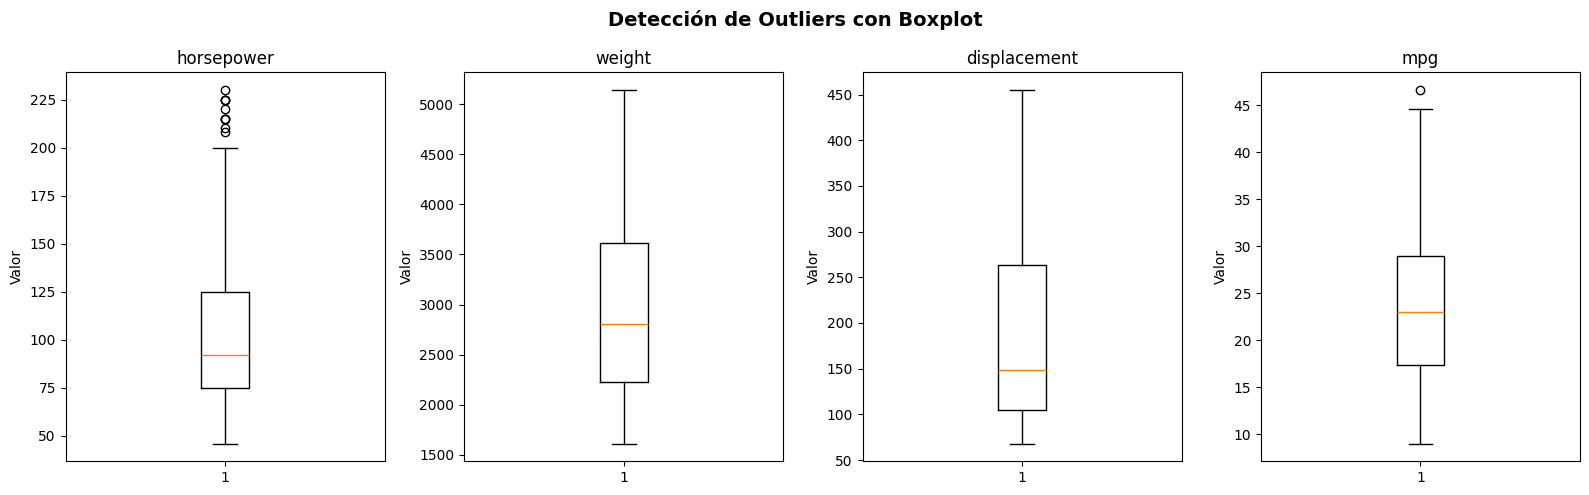


=== Outliers detectados por el método IQR ===
  horsepower: 10 outliers
  weight: 0 outliers
  displacement: 0 outliers
  mpg: 1 outliers


In [6]:
# ── 4. DATOS ANÓMALOS (OUTLIERS) ────────────────────────────────────────────
# Usamos el método IQR (Rango intercuartílico) para detectar outliers
# en las variables que vamos a usar en el modelo.
import matplotlib.pyplot as plt

variables_modelo = ['horsepower', 'weight', 'displacement', 'mpg']

fig, axes = plt.subplots(1, 4, figsize=(16, 5))
fig.suptitle('Detección de Outliers con Boxplot', fontsize=14, fontweight='bold')

for ax, col in zip(axes, variables_modelo):
    ax.boxplot(df[col].dropna())
    ax.set_title(col)
    ax.set_ylabel('Valor')

plt.tight_layout()
plt.show()

# Contamos cuántos outliers hay por columna con el criterio IQR
print("\n=== Outliers detectados por el método IQR ===")
for col in variables_modelo:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df[(df[col] < Q1 - 1.5 * IQR) | (df[col] > Q3 + 1.5 * IQR)]
    print(f"  {col}: {len(outliers)} outliers")

### Decisión sobre los outliers

Se detectaron algunos valores extremos en `horsepower` y `mpg`, pero se decidió **conservarlos** por las siguientes razones:

1. Son valores físicamente posibles (no son errores de medición).
2. El dataset es pequeño (~390 filas), por lo que eliminar filas reduciría significativamente la información disponible.
3. La regresión lineal ordinaria no es tan sensible a outliers moderados como otros modelos.

Si el rendimiento fuera muy bajo, se podría re-evaluar esta decisión aplicando winsorización o eliminación selectiva.

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

# 1. Separamos los datos: X son las características del carro, Y es el consumo (mpg)
X = df[['horsepower', 'weight', 'displacement']]
y = df['mpg']

# 2. Dividimos en entrenamiento (80%) y prueba (20%)
# Justificación del split 80/20:
# Con ~390 datos, este es el split estándar: da suficientes datos para que el modelo
# aprenda (≈312 filas) y suficientes para una evaluación confiable (≈78 filas).
# random_state=42 garantiza reproducibilidad del experimento.
X_entrena, X_prueba, y_entrena, y_prueba = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Datos de entrenamiento: {X_entrena.shape[0]} filas")
print(f"Datos de prueba:        {X_prueba.shape[0]} filas")

# 3. Estandarización (StandardScaler)
# Justificación: horsepower (~46-230), weight (~1600-5100) y displacement (~68-455)
# están en escalas muy diferentes. Sin estandarizar, el modelo le daría más peso
# implícitamente a las variables con números más grandes.
# StandardScaler transforma cada variable para que tenga media=0 y desviación estándar=1.
# IMPORTANTE: el escalador se ajusta SOLO con datos de entrenamiento para evitar
# data leakage (filtración de información del conjunto de prueba).
escalador = StandardScaler()
X_entrena_listo = escalador.fit_transform(X_entrena)
X_prueba_listo = escalador.transform(X_prueba)  # solo transform, no fit

# 4. Creamos y entrenamos el modelo de regresión lineal
modelo = LinearRegression()
modelo.fit(X_entrena_listo, y_entrena)

print("\nModelo entrenado y listo para evaluar")
print(f"Coeficientes: horsepower={modelo.coef_[0]:.2f}, weight={modelo.coef_[1]:.2f}, displacement={modelo.coef_[2]:.2f}")
print(f"Intercepto (beta_0): {modelo.intercept_:.2f}")

Datos de entrenamiento: 316 filas
Datos de prueba:        80 filas

Modelo entrenado y listo para evaluar
Coeficientes: horsepower=-1.70, weight=-4.56, displacement=-0.70
Intercepto (beta_0): 23.79


In [8]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# El modelo predice sobre los datos de prueba que nunca vio
predicciones = modelo.predict(X_prueba_listo)

# Métricas de evaluación
nota_r2  = r2_score(y_prueba, predicciones)
error_mse = mean_squared_error(y_prueba, predicciones)
error_rmse = np.sqrt(error_mse)

print("════════════════════════════")
print("   RESULTADOS DEL MODELO   ")
print("════════════════════════════")
print(f"  R²   (coef. determinación): {nota_r2:.4f}")
print(f"  MSE  (error cuadrático med): {error_mse:.4f}")
print(f"  RMSE (raíz del MSE):         {error_rmse:.4f} mpg")
print("════════════════════════════")
print()
print("Interpretación:")
print(f"  El modelo explica el {nota_r2*100:.1f}% de la variación en el consumo de combustible.")
print(f"  En promedio, el modelo se equivoca por ±{error_rmse:.2f} mpg.")

════════════════════════════
   RESULTADOS DEL MODELO   
════════════════════════════
  R²   (coef. determinación): 0.6229
  MSE  (error cuadrático med): 19.5654
  RMSE (raíz del MSE):         4.4233 mpg
════════════════════════════

Interpretación:
  El modelo explica el 62.3% de la variación en el consumo de combustible.
  En promedio, el modelo se equivoca por ±4.42 mpg.


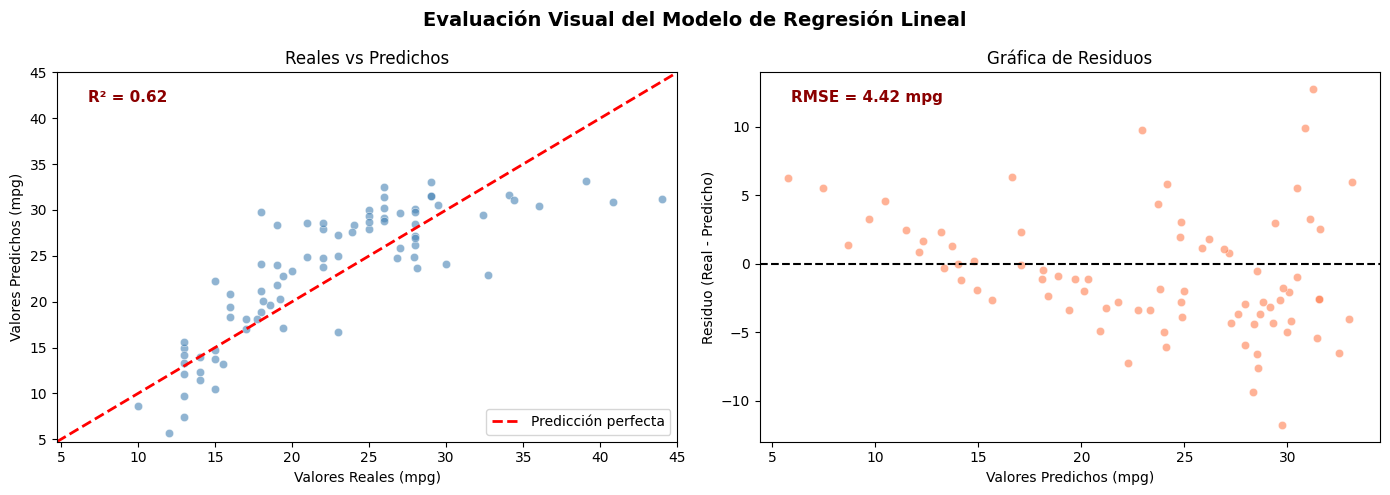


Lectura de las gráficas:
  Izquierda: Los puntos deberían estar cerca de la línea roja. Entre más cerca, mejor predice el modelo.
  Derecha:   Los residuos deberían estar distribuidos aleatoriamente alrededor del 0.
             Si forman un patrón, el modelo tiene un sesgo sistemático.


In [9]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Evaluación Visual del Modelo de Regresión Lineal', fontsize=14, fontweight='bold')

# ── Gráfica 1: Valores reales vs predichos ──────────────────────────────────
ax1 = axes[0]
ax1.scatter(y_prueba, predicciones, alpha=0.6, color='steelblue', edgecolors='white', linewidth=0.5)
lim_min = min(y_prueba.min(), predicciones.min()) - 1
lim_max = max(y_prueba.max(), predicciones.max()) + 1
ax1.plot([lim_min, lim_max], [lim_min, lim_max], 'r--', linewidth=2, label='Predicción perfecta')
ax1.set_xlabel('Valores Reales (mpg)')
ax1.set_ylabel('Valores Predichos (mpg)')
ax1.set_title('Reales vs Predichos')
ax1.legend()
ax1.set_xlim(lim_min, lim_max)
ax1.set_ylim(lim_min, lim_max)
ax1.text(0.05, 0.92, f'R² = {nota_r2:.2f}', transform=ax1.transAxes,
         fontsize=11, color='darkred', fontweight='bold')

# ── Gráfica 2: Residuos ─────────────────────────────────────────────────────
residuos = y_prueba.values - predicciones
ax2 = axes[1]
ax2.scatter(predicciones, residuos, alpha=0.6, color='coral', edgecolors='white', linewidth=0.5)
ax2.axhline(0, color='black', linewidth=1.5, linestyle='--')
ax2.set_xlabel('Valores Predichos (mpg)')
ax2.set_ylabel('Residuo (Real - Predicho)')
ax2.set_title('Gráfica de Residuos')
ax2.text(0.05, 0.92, f'RMSE = {error_rmse:.2f} mpg', transform=ax2.transAxes,
         fontsize=11, color='darkred', fontweight='bold')

plt.tight_layout()
plt.show()

print("")
print("Lectura de las gráficas:")
print("  Izquierda: Los puntos deberían estar cerca de la línea roja. Entre más cerca, mejor predice el modelo.")
print("  Derecha:   Los residuos deberían estar distribuidos aleatoriamente alrededor del 0.")
print("             Si forman un patrón, el modelo tiene un sesgo sistemático.")